In [1]:
import torch
import torch.nn as nn              # Contient les briques de réseaux de neurones (Conv2d, Linear, etc.)
import torch.nn.functional as F    # Fonctions comme relu, softmax, etc. (version "fonctionnelle")
import torch.optim as optim        # Optimiseurs (SGD, Adam, ...)
from torch.utils.data import DataLoader  # Pour charger les données par batchs

import torchvision                          # Bibliothèque pour la vision par ordinateur
import torchvision.transforms as transforms # Pour transformer/normaliser les images

import matplotlib.pyplot as plt    # Pour visualiser les images et les courbes
import numpy as np

In [2]:
# On fixe une graine aléatoire pour que les résultats soient reproductibles
torch.manual_seed(42)

In [4]:
# On définit une "pipeline" de transformations appliquée à chaque image
transform = transforms.Compose([
    transforms.ToTensor(),  # Convertit l'image PIL (0-255) en tenseur PyTorch (0.0-1.0)
    transforms.Normalize((0.1307,), (0.3081,))  # Normalise avec la moyenne/écart-type de MNIST
])

In [5]:
# Téléchargement du dataset d'entraînement (60 000 images)
# On utilise torchvision, une classe qui sait automatiquement télécharger et parser les fichiers MNIST originaux.
train_dataset = torchvision.datasets.MNIST(
    root='./data',       # Dossier où seront stockées les données
    train=True,           # On veut le jeu d'entraînement
    download=True,        # Télécharge si pas déjà présent
    transform=transform   # Applique nos transformations définies plus haut
)

# Téléchargement du dataset de test (10 000 images)
test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,          # On veut le jeu de test
    download=True,
    transform=transform
)

print(f"Nombre d'images d'entraînement : {len(train_dataset)}")
print(f"Nombre d'images de test : {len(test_dataset)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 479kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.49MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.8MB/s]

Nombre d'images d'entraînement : 60000
Nombre d'images de test : 10000


In [8]:
# Créons les DataLoaders
batch_size = 64  # Nombre d'images traitées en même temps à chaque étape

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True    # Mélange les données à chaque epoch (évite que le modèle apprenne un ordre)
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False   # Pas besoin de mélanger pour l'évaluation
)

print(f"Nombre de batchs d'entraînement : {len(train_loader)}")
print(f"Nombre de batchs de test : {len(test_loader)}")

Nombre de batchs d'entraînement : 938
Nombre de batchs de test : 157


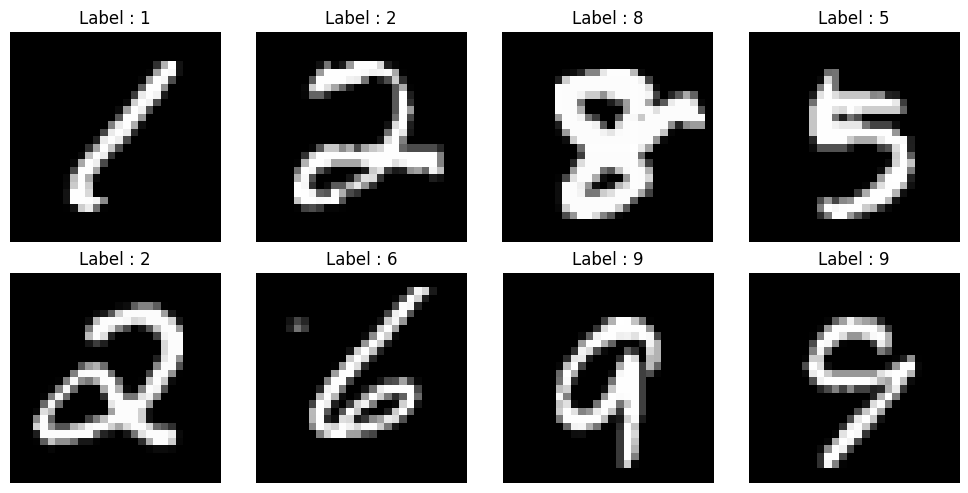

Forme d'une image : torch.Size([1, 28, 28])


In [9]:
# On récupère un batch d'images et labels
examples = iter(train_loader)
images, labels = next(examples)

# On affiche les 8 premières images du batch
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    # On "dénormalise" un peu pour un affichage correct (optionnel mais plus lisible)
    img = images[i][0] * 0.3081 + 0.1307
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Label : {labels[i].item()}")
    ax.axis('off')
plt.tight_layout()
plt.show()

print(f"Forme d'une image : {images[0].shape}")  # Devrait être [1, 28, 28] : 1 canal, 28x28 pixels

In [10]:
class SimpleCNN(nn.Module):
    """
    Un CNN simple pour classifier les chiffres MNIST (0-9).
    Architecture : 2 blocs convolutionnels + 2 couches linéaires.
    """
    def __init__(self):
        super(SimpleCNN, self).__init__()  # Initialise la classe parente nn.Module

        # --- Bloc convolutionnel 1 ---
        # in_channels=1 car image en niveaux de gris (1 seul canal)
        # out_channels=32 : on crée 32 "filtres" différents, donc 32 cartes de features en sortie
        # kernel_size=3 : chaque filtre fait 3x3 pixels
        # padding=1 : on ajoute une bordure de 1 pixel pour garder la même taille (28x28) après convolution
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)

        # --- Bloc convolutionnel 2 ---
        # in_channels=32 car on reçoit les 32 cartes de features du bloc précédent
        # out_channels=64 : on augmente le nombre de filtres pour détecter des motifs plus complexes
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        # --- Pooling ---
        # kernel_size=2, stride=2 : divise la taille par 2 (28→14, puis 14→7)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # --- Couches entièrement connectées (fully connected) ---
        # Après 2 poolings : 28 -> 14 -> 7, donc l'image finale fait 7x7 avec 64 canaux
        # 64 * 7 * 7 = 3136 valeurs à "aplatir" en un vecteur
        self.fc1 = nn.Linear(in_features=64 * 7 * 7, out_features=128)
        self.fc2 = nn.Linear(in_features=128, out_features=10)  # 10 classes = chiffres 0-9

        # --- Dropout (optionnel mais recommandé) ---
        # Désactive aléatoirement 25% des neurones pendant l'entraînement pour éviter le sur-apprentissage
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        """
        Définit comment les données circulent à travers le réseau.
        x a la forme : [batch_size, 1, 28, 28]
        """
        # Bloc 1 : conv -> activation -> pooling
        x = self.conv1(x)          # [batch, 32, 28, 28]
        x = F.relu(x)               # Activation non-linéaire
        x = self.pool(x)            # [batch, 32, 14, 14]

        # Bloc 2 : conv -> activation -> pooling
        x = self.conv2(x)          # [batch, 64, 14, 14]
        x = F.relu(x)
        x = self.pool(x)            # [batch, 64, 7, 7]

        # On aplatit le tenseur pour passer aux couches linéaires
        # x.size(0) = batch_size (on garde cette dimension), -1 = tout le reste aplati
        x = x.view(x.size(0), -1)   # [batch, 64*7*7] = [batch, 3136]

        # Couches linéaires avec dropout
        x = self.dropout(x)
        x = F.relu(self.fc1(x))     # [batch, 128]
        x = self.fc2(x)             # [batch, 10] — scores bruts (logits), pas encore de probabilités

        return x

In [11]:
model = SimpleCNN().to(device)  # On envoie le modèle sur GPU/CPU selon ce qui est disponible
print(model)

# On compte le nombre de paramètres entraînables (pour ton rapport, c'est une info intéressante)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nNombre total de paramètres entraînables : {num_params:,}")

SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
)

Nombre total de paramètres entraînables : 421,642


In [12]:
# On prend un batch réel de nos données
dataiter = iter(train_loader)
images, labels = next(dataiter)
images = images.to(device)

# On passe ce batch dans le modèle (sans entraîner, juste un test de forme)
output = model(images)
print(f"Forme de l'entrée  : {images.shape}")   # [64, 1, 28, 28]
print(f"Forme de la sortie : {output.shape}")   # [64, 10] — 10 scores par image du batch

Forme de l'entrée  : torch.Size([64, 1, 28, 28])
Forme de la sortie : torch.Size([64, 10])


In [13]:
# CrossEntropyLoss : la fonction de perte standard pour la classification multi-classes.
# Elle applique un softmax en interne + calcule l'erreur par rapport au vrai label.
criterion = nn.CrossEntropyLoss()

# Adam : un optimiseur qui ajuste automatiquement la vitesse d'apprentissage (learning rate)
# pour chaque paramètre. C'est un excellent choix par défaut, plus rapide à converger que SGD classique.
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [14]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """
    Entraîne le modèle sur un passage complet des données (1 epoch).
    Retourne la perte moyenne et la précision sur cette epoch.
    """
    model.train()  # Passe le modèle en mode "entraînement" (active dropout, etc.)

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        # On envoie les données sur le bon device (GPU/CPU)
        images, labels = images.to(device), labels.to(device)

        # 1. Remise à zéro des gradients (sinon ils s'accumulent d'un batch à l'autre)
        optimizer.zero_grad()

        # 2. Passage avant (forward pass) : le modèle fait ses prédictions
        outputs = model(images)  # [batch, 10]

        # 3. Calcul de la perte (à quel point on s'est trompé)
        loss = criterion(outputs, labels)

        # 4. Rétropropagation (backward pass) : calcule les gradients
        loss.backward()

        # 5. Mise à jour des poids selon les gradients calculés
        optimizer.step()

        # --- Statistiques pour suivre la progression ---
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)  # Classe prédite = celle avec le score le plus haut
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [15]:
def evaluate(model, loader, criterion, device):
    """
    Évalue le modèle sur un jeu de données, SANS mettre à jour les poids.
    """
    model.eval()  # Mode évaluation (désactive dropout, etc.)

    running_loss = 0.0
    correct = 0
    total = 0

    # torch.no_grad() : on désactive le calcul des gradients (pas besoin en évaluation)
    # Ça économise de la mémoire et accélère les calculs
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [16]:
num_epochs = 10  # Nombre de passages complets sur les données d'entraînement

# On garde l'historique pour pouvoir tracer des courbes ensuite
history = {
    'train_loss': [], 'train_acc': [],
    'test_loss': [], 'test_acc': []
}

print("Début de l'entraînement...\n")

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    # On enregistre les résultats
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

print("\nEntraînement terminé ✅")

Début de l'entraînement...

Epoch [1/10] Train Loss: 0.1430 | Train Acc: 0.9549 | Test Loss: 0.0492 | Test Acc: 0.9845
Epoch [2/10] Train Loss: 0.0495 | Train Acc: 0.9845 | Test Loss: 0.0311 | Test Acc: 0.9899
Epoch [3/10] Train Loss: 0.0350 | Train Acc: 0.9891 | Test Loss: 0.0249 | Test Acc: 0.9920
Epoch [4/10] Train Loss: 0.0279 | Train Acc: 0.9910 | Test Loss: 0.0271 | Test Acc: 0.9916
Epoch [5/10] Train Loss: 0.0228 | Train Acc: 0.9929 | Test Loss: 0.0318 | Test Acc: 0.9905
Epoch [6/10] Train Loss: 0.0178 | Train Acc: 0.9944 | Test Loss: 0.0279 | Test Acc: 0.9917
Epoch [7/10] Train Loss: 0.0164 | Train Acc: 0.9947 | Test Loss: 0.0273 | Test Acc: 0.9913
Epoch [8/10] Train Loss: 0.0146 | Train Acc: 0.9950 | Test Loss: 0.0297 | Test Acc: 0.9921
Epoch [9/10] Train Loss: 0.0120 | Train Acc: 0.9958 | Test Loss: 0.0329 | Test Acc: 0.9905
Epoch [10/10] Train Loss: 0.0131 | Train Acc: 0.9957 | Test Loss: 0.0230 | Test Acc: 0.9944

Entraînement terminé ✅


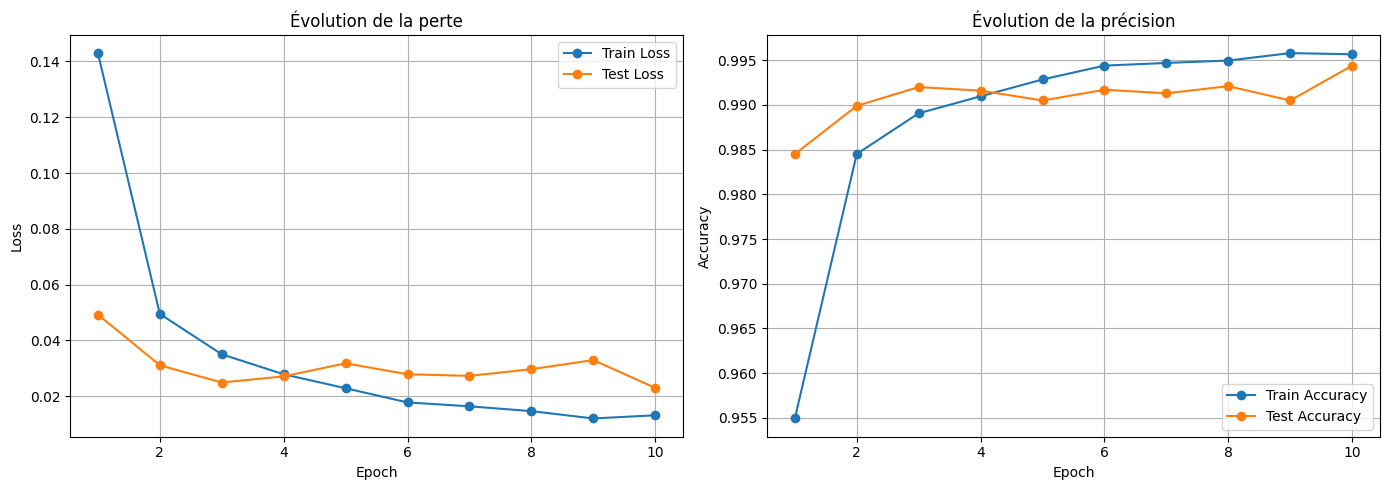

In [21]:
epochs_range = range(1, num_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(epochs_range, history['test_loss'], label='Test Loss', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Évolution de la perte')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_range, history['train_acc'], label='Train Accuracy', marker='o')
axes[1].plot(epochs_range, history['test_acc'], label='Test Accuracy', marker='o')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Évolution de la précision')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')  # ← Nouvelle ligne : sauvegarde AVANT show()
plt.show()

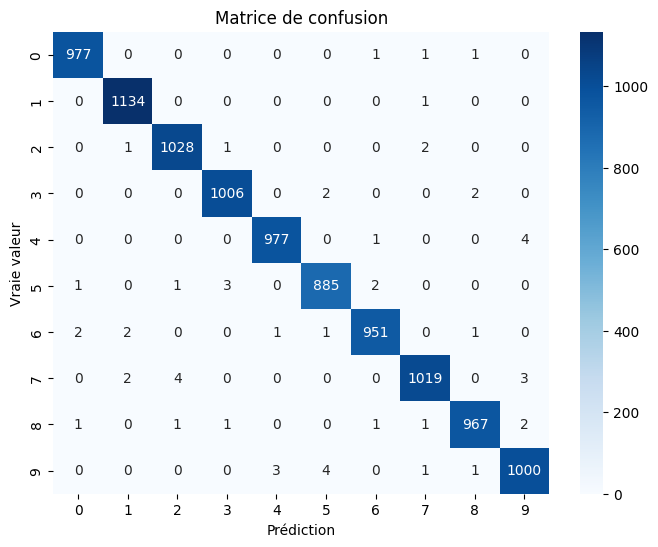

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prédiction')
plt.ylabel('Vraie valeur')
plt.title('Matrice de confusion')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
from google.colab import files
files.download('training_curves.png')
files.download('confusion_matrix.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

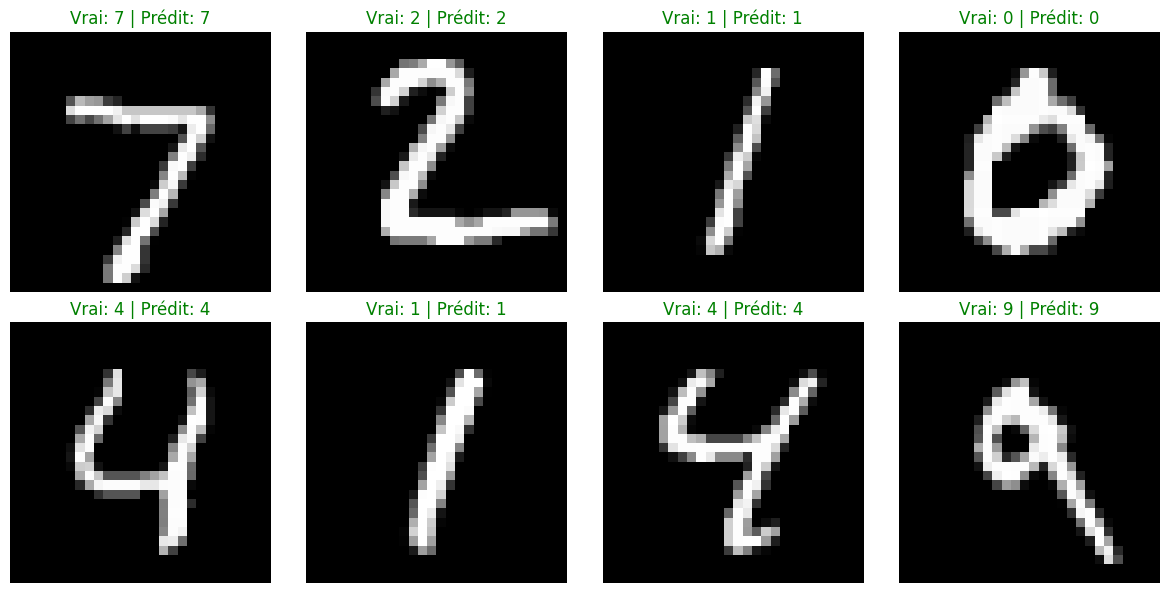

In [19]:
# On récupère un batch du test set
dataiter = iter(test_loader)
images, labels = next(dataiter)
images_device = images.to(device)

model.eval()
with torch.no_grad():
    outputs = model(images_device)
    _, preds = torch.max(outputs, 1)

preds = preds.cpu()

# On affiche 8 exemples avec prédiction vs vraie valeur
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    img = images[i][0] * 0.3081 + 0.1307  # dénormalisation pour affichage
    ax.imshow(img, cmap='gray')
    correct = preds[i].item() == labels[i].item()
    color = 'green' if correct else 'red'
    ax.set_title(f"Vrai: {labels[i].item()} | Prédit: {preds[i].item()}", color=color)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [20]:
# On sauvegarde uniquement les poids (state_dict) — c'est la méthode recommandée en PyTorch
# plutôt que de sauvegarder l'objet modèle entier (plus portable et plus sûr)
torch.save(model.state_dict(), 'mnist_cnn.pth')

print("Modèle sauvegardé sous 'mnist_cnn.pth' ✅")

# Vérification : taille du fichier
import os
size_kb = os.path.getsize('mnist_cnn.pth') / 1024
print(f"Taille du fichier : {size_kb:.1f} KB")

Modèle sauvegardé sous 'mnist_cnn.pth' ✅
Taille du fichier : 1650.6 KB
